- load data
- check dataset
- unwrap lists & dict in columns
- remove duplicate
- handle missing values
- fix data types
- handle outliers
- clean categorical data

In [13]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [14]:
data_folder=Path('./data')

def read_json(file_path):
    with open(file_path, 'r') as f: 
        try: 
            return json.load(f) 
        except json.JSONDecodeError:
            f.seek(0)
            return[json.loads(line) for line in f if line.strip()]

In [15]:
portfolio_data = read_json(data_folder/'portfolio.json')
profile_data = read_json(data_folder/'profile.json')
transcript_data = read_json(data_folder/'transcript.json')

### Transform to DataFrame

In [16]:
print(type(portfolio_data))

<class 'list'>


In [17]:
portfolio_data = pd.DataFrame(portfolio_data)
profile_data = pd.DataFrame(profile_data)
transcript_data = pd.DataFrame(transcript_data)

# Pre-processing

## portfolio data

In [18]:
portfolio_data

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7.0,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4.0,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7.0,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5.0,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7.0,discount,2906b810c7d4411798c6938adc9daaa5


In [19]:
portfolio_data.rename(columns={'id': 'offer_id'}, inplace=True)

In [20]:
portfolio_data.rename(columns={'reward': 'spending_reward'}, inplace=True)

In [21]:
portfolio_data.describe()

,spending_reward,difficulty,duration
count,10.000000,10.000000,10.000000
mean,4.200000,7.700000,6.500000
std,3.583915,5.831905,2.321398
min,0.000000,0.000000,3.000000
25%,2.000000,5.000000,5.000000
50%,4.000000,8.500000,7.000000
75%,5.000000,10.000000,7.000000
max,10.000000,20.000000,10.000000


In [22]:
portfolio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   spending_reward  10 non-null     int64  
 1   channels         10 non-null     object 
 2   difficulty       10 non-null     int64  
 3   duration         10 non-null     float64
 4   offer_type       10 non-null     object 
 5   offer_id         10 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 612.0+ bytes


In [23]:
portfolio_data.isnull().sum()

spending_reward    0
channels           0
difficulty         0
duration           0
offer_type         0
offer_id           0
dtype: int64

In [25]:
print('unique values in reward column:', portfolio_data['spending_reward'].unique())
print('unique values in difficulty column:', portfolio_data['difficulty'].unique())
print('unique values in offer_type column:', portfolio_data['offer_type'].unique())
print('dataset shape:', portfolio_data.shape)

unique values in reward column: [10  0  5  3  2]
unique values in difficulty column: [10  0  5 20  7]
unique values in offer_type column: ['bogo' 'informational' 'discount']
dataset shape: (10, 6)


### Transform channels column to 4 columns

In [26]:
# unwrap list
portfolio_data['web']=portfolio_data['channels'].apply(lambda x: 1 if 'web' in x else 0)
portfolio_data['mobile']=portfolio_data['channels'].apply(lambda x: 1 if 'mobile' in x else 0)
portfolio_data['social']=portfolio_data['channels'].apply(lambda x: 1 if 'social' in x else 0)
portfolio_data['email']=portfolio_data['channels'].apply(lambda x: 1 if 'email' in x else 0)    

In [27]:
portfolio_data = portfolio_data.drop(columns=['channels'])

In [28]:
portfolio_data

,spending_reward,difficulty,duration,offer_type,offer_id,web,mobile,social,email
0,10,10,7.0,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1
1,10,10,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4.0,informational,3f207df678b143eea3cee63160fa8bed,1,1,0,1
3,5,5,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,0,1
4,5,20,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,0,0,1
5,3,7,7.0,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1
6,2,10,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1
7,0,0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1
8,5,5,5.0,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1
9,2,10,7.0,discount,2906b810c7d4411798c6938adc9daaa5,1,1,0,1


In [29]:
portfolio_data.drop_duplicates()

,spending_reward,difficulty,duration,offer_type,offer_id,web,mobile,social,email
0,10,10,7.0,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1
1,10,10,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4.0,informational,3f207df678b143eea3cee63160fa8bed,1,1,0,1
3,5,5,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,0,1
4,5,20,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,0,0,1
5,3,7,7.0,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1
6,2,10,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1
7,0,0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1
8,5,5,5.0,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1
9,2,10,7.0,discount,2906b810c7d4411798c6938adc9daaa5,1,1,0,1


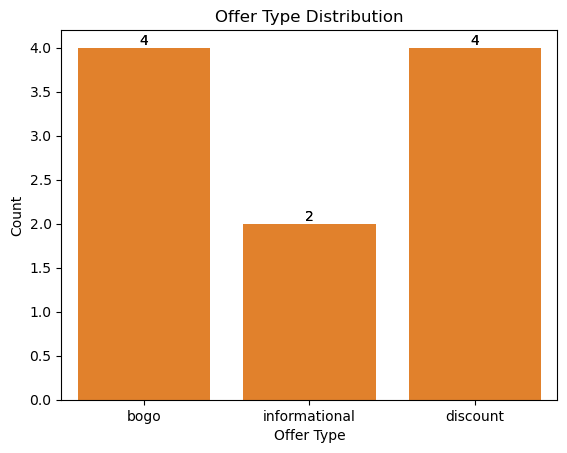

In [30]:
sns.countplot(x='offer_type', data=portfolio_data)

ax = sns.countplot(x='offer_type', data=portfolio_data)

# add numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Offer Type Distribution')
plt.xlabel('Offer Type')
plt.ylabel('Count')
plt.show()

## profile data

In [31]:
profile_data

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


In [32]:
profile_data.describe()

,age,income
count,17000.000000,14825.000000
mean,62.531412,65404.991568
std,26.738580,21598.299410
min,18.000000,30000.000000
25%,45.000000,49000.000000
50%,58.000000,64000.000000
75%,73.000000,80000.000000
max,118.000000,120000.000000


In [33]:
profile_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  object 
 4   income            14825 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 664.2+ KB


In [34]:
profile_data=profile_data.drop_duplicates()

In [35]:
profile_data.isnull().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [36]:
2175/17000*100

12.794117647058822

In [37]:
(profile_data['age'] == 118).sum()

2175

In [38]:
profile_data.dropna(inplace=True)

In [39]:
profile_data.isnull().sum()

gender              0
age                 0
id                  0
became_member_on    0
income              0
dtype: int64

In [40]:
profile_data['became_member_on'] = pd.to_datetime(
    profile_data['became_member_on'], format='%Y%m%d'
)

In [41]:
profile_data

,gender,age,id,became_member_on,income
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0
5,M,68,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0
8,M,65,389bc3fa690240e798340f5a15918d5c,2018-02-09,53000.0
12,M,58,2eeac8d8feae4a8cad5a6af0499a211d,2017-11-11,51000.0
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,2018-06-04,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,2018-07-13,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,2017-01-26,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,2016-03-07,50000.0


In [42]:
import datetime as dt

profile_data['member_days'] = (pd.Timestamp.today() - profile_data['became_member_on']).dt.days

In [43]:
profile_data

,gender,age,id,became_member_on,income,member_days
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,3225
5,M,68,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0,2873
8,M,65,389bc3fa690240e798340f5a15918d5c,2018-02-09,53000.0,2949
12,M,58,2eeac8d8feae4a8cad5a6af0499a211d,2017-11-11,51000.0,3039
...,...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,2018-06-04,54000.0,2834
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,2018-07-13,72000.0,2795
16997,M,49,01d26f638c274aa0b965d24cefe3183f,2017-01-26,73000.0,3328
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,2016-03-07,50000.0,3653


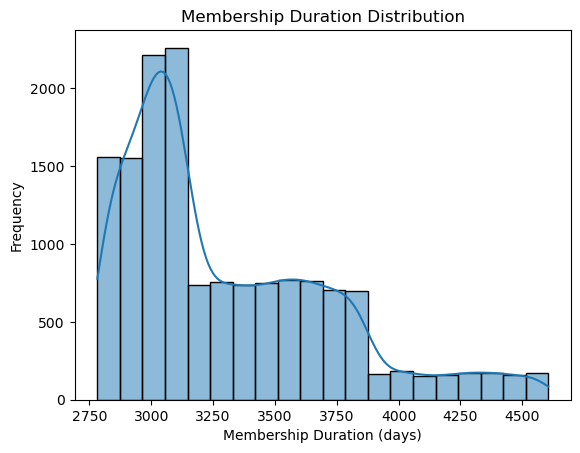

In [44]:
sns.histplot(profile_data['member_days'], bins=20, kde=True)
plt.title('Membership Duration Distribution')
plt.xlabel('Membership Duration (days)')
plt.ylabel('Frequency')
plt.show()

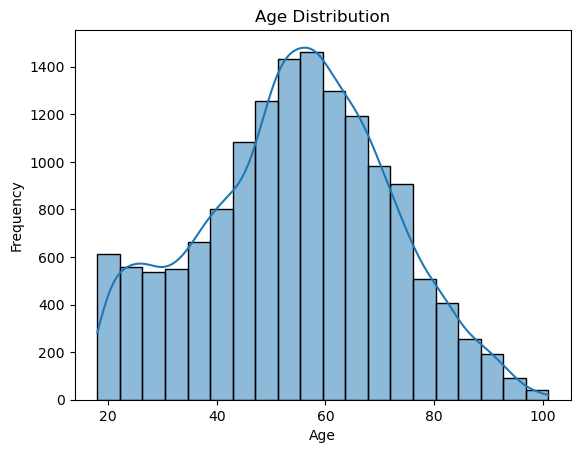

In [45]:
sns.histplot(profile_data['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

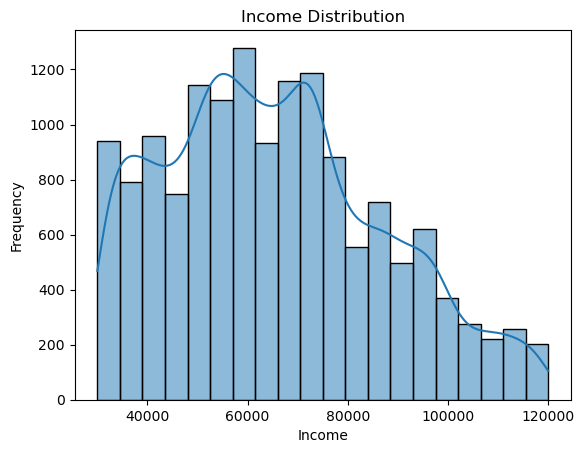

In [46]:
sns.histplot(profile_data['income'], bins=20, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

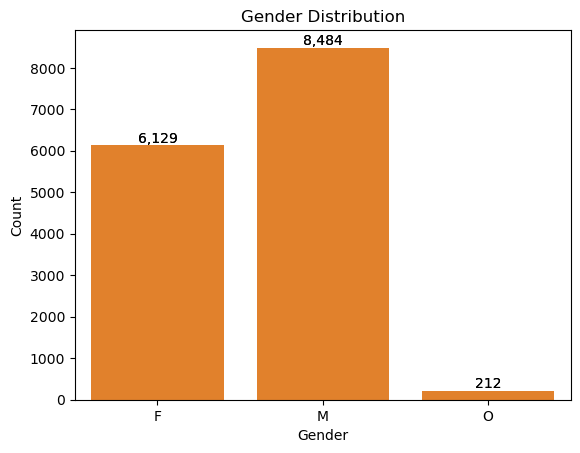

In [47]:
sns.countplot(x='gender', data=profile_data)

ax = sns.countplot(x='gender', data=profile_data)

# add numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## transcript data

In [48]:
transcript_data

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.59},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.53},714


In [49]:
print('unique value in event column:', transcript_data['event'].unique())

unique value in event column: ['offer received' 'offer viewed' 'transaction' 'offer completed']


In [50]:
transcript_data.describe()

,time
count,306534.000000
mean,366.382940
std,200.326314
min,0.000000
25%,186.000000
50%,408.000000
75%,528.000000
max,714.000000


In [51]:
transcript_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB


In [52]:
transcript_data.isnull().sum()

person    0
event     0
value     0
time      0
dtype: int64

### Transform event column to 3 columns

In [53]:
transcript_data['offer_received']=transcript_data['event'].apply(lambda x: 1 if 'offer received' in x else 0)

In [54]:
transcript_data['offer_viewed']=transcript_data['event'].apply(lambda x: 1 if 'offer viewed' in x else 0)
transcript_data['transaction']=transcript_data['event'].apply(lambda x: 1 if 'transaction' in x else 0)
transcript_data['offer_completed']=transcript_data['event'].apply(lambda x: 1 if 'offer completed' in x else 0)

In [55]:
transcript_data.drop(columns=['event'], inplace=True)

In [56]:
transcript_data.rename(columns={'person': 'id'}, inplace=True)

In [57]:
transcript_data.rename(columns={'reward': 'offer_reward'}, inplace=True)

In [58]:
transcript_data

,id,value,time,offer_received,offer_viewed,transaction,offer_completed
0,78afa995795e4d85b5d9ceeca43f5fef,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,1,0,0,0
1,a03223e636434f42ac4c3df47e8bac43,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,1,0,0,0
2,e2127556f4f64592b11af22de27a7932,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,1,0,0,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,1,0,0,0
4,68617ca6246f4fbc85e91a2a49552598,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,1,0,0,0
...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,{'amount': 1.59},714,0,0,1,0
306530,68213b08d99a4ae1b0dcb72aebd9aa35,{'amount': 9.53},714,0,0,1,0
306531,a00058cf10334a308c68e7631c529907,{'amount': 3.61},714,0,0,1,0
306532,76ddbd6576844afe811f1a3c0fbb5bec,{'amount': 3.53},714,0,0,1,0


### Transform value column to 3 columns

In [59]:
transcript_data['offer_id'] = transcript_data['value'].apply(lambda x: x.get('offer_id', x.get('offer id', 0)))
transcript_data['amount'] = transcript_data['value'].apply(lambda x: x.get('amount', x.get('amount', 0)))
transcript_data['reward'] = transcript_data['value'].apply(lambda x: x.get('reward', x.get('reward', 0)))

In [60]:
transcript_data.drop(columns='value', inplace=True)

In [61]:
transcript_data

,id,time,offer_received,offer_viewed,transaction,offer_completed,offer_id,amount,reward
0,78afa995795e4d85b5d9ceeca43f5fef,0,1,0,0,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,0.00,0
1,a03223e636434f42ac4c3df47e8bac43,0,1,0,0,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,0.00,0
2,e2127556f4f64592b11af22de27a7932,0,1,0,0,0,2906b810c7d4411798c6938adc9daaa5,0.00,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,0,1,0,0,0,fafdcd668e3743c1bb461111dcafc2a4,0.00,0
4,68617ca6246f4fbc85e91a2a49552598,0,1,0,0,0,4d5c57ea9a6940dd891ad53e9dbe8da0,0.00,0
...,...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,714,0,0,1,0,0,1.59,0
306530,68213b08d99a4ae1b0dcb72aebd9aa35,714,0,0,1,0,0,9.53,0
306531,a00058cf10334a308c68e7631c529907,714,0,0,1,0,0,3.61,0
306532,76ddbd6576844afe811f1a3c0fbb5bec,714,0,0,1,0,0,3.53,0


In [62]:
transcript_data.isnull().sum()

id                 0
time               0
offer_received     0
offer_viewed       0
transaction        0
offer_completed    0
offer_id           0
amount             0
reward             0
dtype: int64

In [63]:
transcript_data['offer_received'].sum()

76277

In [64]:
transcript_data['offer_viewed'].sum()

57725

In [65]:
transcript_data['transaction'].sum()

138953

In [66]:
transcript_data['offer_completed'].sum()

33579

In [67]:
transcript_data.drop_duplicates(inplace=True)

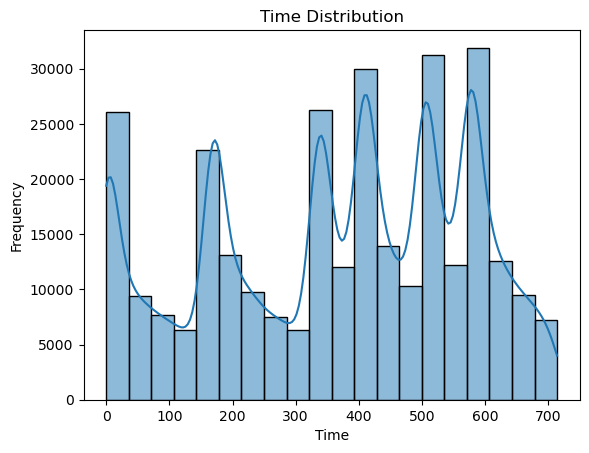

In [68]:
sns.histplot(transcript_data['time'], bins=20, kde=True)
plt.title('Time Distribution')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

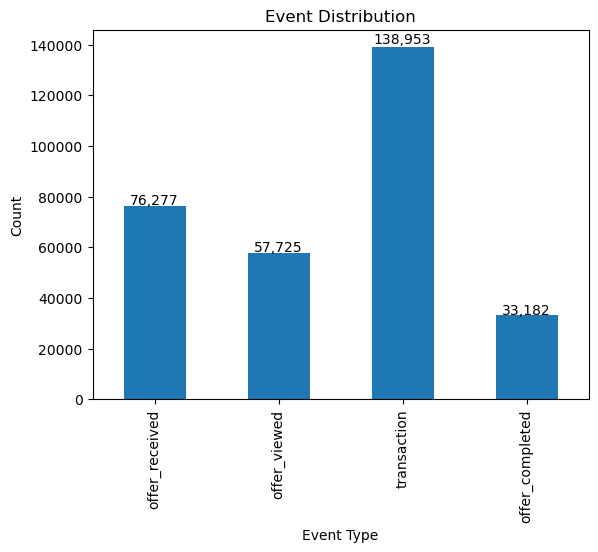

In [69]:
event_counts = transcript_data[['offer_received','offer_viewed','transaction','offer_completed']].sum()

event_counts.plot(kind='bar')

ax = event_counts.plot(kind='bar') 

# add numbers on top of bars
for i, v in enumerate(event_counts):
    ax.text(i, v*1.01, f'{int(v):,}', ha='center')

plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

# Merge Datasets

In [70]:
df = profile_data.merge(transcript_data, on='id', how='inner')

In [71]:
df = df.merge(portfolio_data, on='offer_id', how='left')

In [72]:
df

,gender,age,id,became_member_on,income,member_days,time,offer_received,offer_viewed,transaction,...,amount,reward,spending_reward,difficulty,duration,offer_type,web,mobile,social,email
0,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158,18,0,0,1,...,21.51,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158,144,0,0,1,...,32.28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158,408,1,0,0,...,0.00,0,5.0,5.0,7.0,bogo,1.0,1.0,0.0,1.0
3,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158,504,1,0,0,...,0.00,0,0.0,0.0,4.0,informational,1.0,1.0,0.0,1.0
4,F,55,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,3158,528,0,0,1,...,23.22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272383,F,62,e4052622e5ba45a8b96b59aba68cf068,2017-07-22,82000.0,3151,480,0,0,0,...,0.00,5,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
272384,F,62,e4052622e5ba45a8b96b59aba68cf068,2017-07-22,82000.0,3151,486,0,0,1,...,19.47,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272385,F,62,e4052622e5ba45a8b96b59aba68cf068,2017-07-22,82000.0,3151,546,0,1,0,...,0.00,0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
272386,F,62,e4052622e5ba45a8b96b59aba68cf068,2017-07-22,82000.0,3151,576,1,0,0,...,0.00,0,0.0,0.0,4.0,informational,1.0,1.0,0.0,1.0


In [ ]:
df.isnull().sum()

gender                   0
age                      0
id                       0
became_member_on         0
income                   0
member_days              0
time                     0
offer_received           0
offer_viewed             0
transaction              0
offer_completed          0
offer_id                 0
amount                   0
reward                   0
spending_reward     123957
difficulty          123957
duration            123957
offer_type          123957
web                 123957
mobile              123957
social              123957
email               123957
dtype: int64

In [74]:
df.fillna(0, inplace=True)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272388 entries, 0 to 272387
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   gender            272388 non-null  object        
 1   age               272388 non-null  int64         
 2   id                272388 non-null  object        
 3   became_member_on  272388 non-null  datetime64[ns]
 4   income            272388 non-null  float64       
 5   member_days       272388 non-null  int64         
 6   time              272388 non-null  int64         
 7   offer_received    272388 non-null  int64         
 8   offer_viewed      272388 non-null  int64         
 9   transaction       272388 non-null  int64         
 10  offer_completed   272388 non-null  int64         
 11  offer_id          272388 non-null  object        
 12  amount            272388 non-null  float64       
 13  reward            272388 non-null  int64         
 14  spen

In [76]:
df.drop(columns=['became_member_on', 'offer_id'], inplace=True)

In [77]:
df['bogo']=df['offer_type'].apply(lambda x: 1 if x == 'bogo' else 0)
df['discount']=df['offer_type'].apply(lambda x: 1 if x == 'discount' else 0)
df['informational']=df['offer_type'].apply(lambda x: 1 if x == 'informational' else 0)  

In [78]:
df.drop(columns=['offer_type'], inplace=True)

In [79]:
df

,gender,age,id,income,member_days,time,offer_received,offer_viewed,transaction,offer_completed,...,spending_reward,difficulty,duration,web,mobile,social,email,bogo,discount,informational
0,F,55,0610b486422d4921ae7d2bf64640c50b,112000.0,3158,18,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,F,55,0610b486422d4921ae7d2bf64640c50b,112000.0,3158,144,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,F,55,0610b486422d4921ae7d2bf64640c50b,112000.0,3158,408,1,0,0,0,...,5.0,5.0,7.0,1.0,1.0,0.0,1.0,1,0,0
3,F,55,0610b486422d4921ae7d2bf64640c50b,112000.0,3158,504,1,0,0,0,...,0.0,0.0,4.0,1.0,1.0,0.0,1.0,0,0,1
4,F,55,0610b486422d4921ae7d2bf64640c50b,112000.0,3158,528,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272383,F,62,e4052622e5ba45a8b96b59aba68cf068,82000.0,3151,480,0,0,0,1,...,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1,0,0
272384,F,62,e4052622e5ba45a8b96b59aba68cf068,82000.0,3151,486,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
272385,F,62,e4052622e5ba45a8b96b59aba68cf068,82000.0,3151,546,0,1,0,0,...,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1,0,0
272386,F,62,e4052622e5ba45a8b96b59aba68cf068,82000.0,3151,576,1,0,0,0,...,0.0,0.0,4.0,1.0,1.0,0.0,1.0,0,0,1


In [98]:
len(df['id'].unique())

14825

In [80]:
best_offer = df[['offer_completed', 'bogo', 'discount', 'informational']]

In [105]:
print('completed bogo:', best_offer.loc[best_offer['offer_completed'] > 0, 'bogo'].sum())
print('completed discount:', best_offer.loc[best_offer['offer_completed'] > 0, 'discount'].sum())
print('completed informational:', best_offer.loc[best_offer['offer_completed'] > 0, 'informational'].sum())

completed bogo: 15100
completed discount: 16970
completed informational: 0


In [81]:
best_channel = df[['offer_completed', 'web', 'mobile', 'social', 'email']]

In [82]:
best_channel

,offer_completed,web,mobile,social,email
0,0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0
2,0,1.0,1.0,0.0,1.0
3,0,1.0,1.0,0.0,1.0
4,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
272383,1,1.0,1.0,1.0,1.0
272384,0,0.0,0.0,0.0,0.0
272385,0,1.0,1.0,1.0,1.0
272386,0,1.0,1.0,0.0,1.0


In [83]:
best_offer

,offer_completed,bogo,discount,informational
0,0,0,0,0
1,0,0,0,0
2,0,1,0,0
3,0,0,0,1
4,0,0,0,0
...,...,...,...,...
272383,1,1,0,0
272384,0,0,0,0
272385,0,1,0,0
272386,0,0,0,1


In [84]:
target_customer = df.groupby('id').agg(({
    'age': 'first',
    'income': 'first',
    'income': 'first',
    'offer_completed': 'sum',
}))

In [85]:
target_customer[target_customer['age'] > 100]

,age,income,offer_completed
id,,,
047ad0135cfe4c0ea5ba019da4de9c52,101,59000.0,1
1593d617fac246ef8e50dbb0ffd77f5f,101,82000.0,5
4d2ccfcbbebf4bd9baf4b7e433d0e288,101,43000.0,4
d2fdc2be8ab64e4ba04830d441e53fd5,101,99000.0,1
e0ea90ddd2f147e082d21e97f51ec1b1,101,56000.0,1


In [86]:
target_customer

,age,income,offer_completed
id,,,
0009655768c64bdeb2e877511632db8f,33,72000.0,3
0011e0d4e6b944f998e987f904e8c1e5,40,57000.0,3
0020c2b971eb4e9188eac86d93036a77,59,90000.0,3
0020ccbbb6d84e358d3414a3ff76cffd,24,60000.0,3
003d66b6608740288d6cc97a6903f4f0,26,73000.0,3
...,...,...,...
fff3ba4757bd42088c044ca26d73817a,69,83000.0,3
fff7576017104bcc8677a8d63322b5e1,71,73000.0,3
fff8957ea8b240a6b5e634b6ee8eafcf,71,56000.0,0


In [87]:
target_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14825 entries, 0009655768c64bdeb2e877511632db8f to ffff82501cea40309d5fdd7edcca4a07
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              14825 non-null  int64  
 1   income           14825 non-null  float64
 2   offer_completed  14825 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 979.3+ KB


# Correlation

In [88]:
# best channel
best_channel_corr = best_channel.corr()
best_channel_corr
# web & email have the highest correlation with offer_completed

,offer_completed,web,mobile,social,email
offer_completed,1.000000,0.329788,0.290016,0.219719,0.333833
web,0.329788,1.000000,0.704478,0.402283,0.809292
mobile,0.290016,0.704478,1.000000,0.748289,0.913779
social,0.219719,0.402283,0.748289,1.000000,0.683771
email,0.333833,0.809292,0.913779,0.683771,1.000000


In [89]:
# best offer
best_offer_corr = best_offer.corr()
best_offer_corr
# discount have the highest correlation with offer_completed

,offer_completed,bogo,discount,informational
offer_completed,1.000000,0.204630,0.262267,-0.110041
bogo,0.204630,1.000000,-0.300144,-0.166384
discount,0.262267,-0.300144,1.000000,-0.163686
informational,-0.110041,-0.166384,-0.163686,1.000000


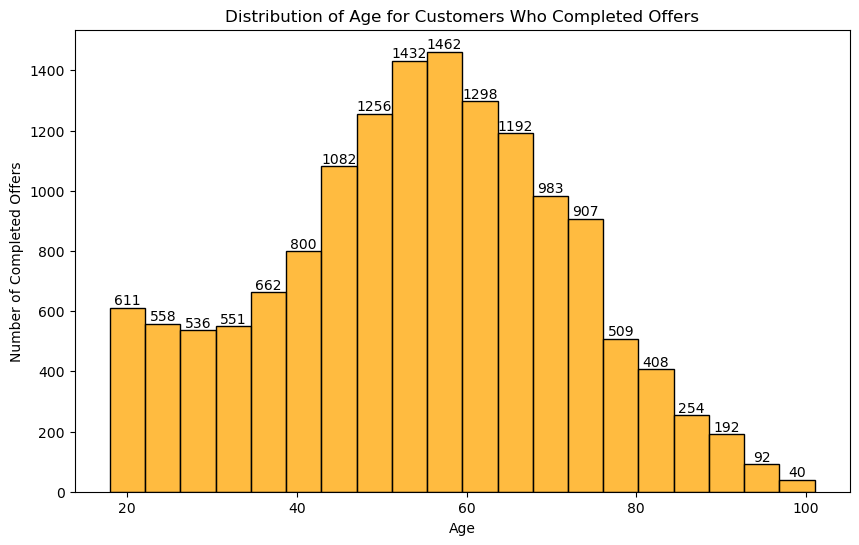

In [90]:
plt.figure(figsize=(10,6))
ax = sns.histplot(target_customer['age'], bins=20, color='orange', kde=False)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Age for Customers Who Completed Offers")
plt.xlabel("Age")
plt.ylabel("Number of Completed Offers")
plt.show()
# customers who aged between 45 - 65

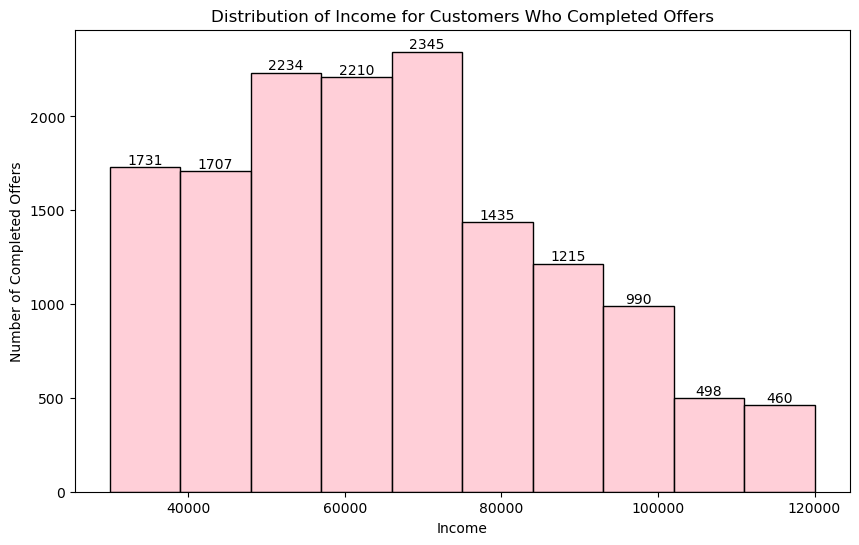

In [91]:
plt.figure(figsize=(10,6))
ax = sns.histplot(target_customer['income'], bins=10, color='pink', kde=False)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Income for Customers Who Completed Offers")
plt.xlabel("Income")
plt.ylabel("Number of Completed Offers")
plt.show()
# customers who have income between 50000 - 70000

# Save Processed Data

In [92]:
target_customer.to_csv('target_customer.csv', index=True)